# Beat Timer v0.3.1 Local Tempo

This revision fixes octave-doubled local BPM estimates, overlapping timing sections, and blank oversized Plotly output in VS Code notebooks.


In [11]:
from pathlib import Path

import librosa
import numpy as np
import plotly.graph_objects as go
from IPython.display import HTML, display
from plotly.subplots import make_subplots


## Configuration

In [56]:
# Change only this path for a new song.
AUDIO_PATH = Path("sakuzyo_that_day.mp3")
OSU_PATH = Path("sakuzyo_that_day.osu")

# Analysis quality. Keep 256 while developing; use 32 or 16 for a precision pass.
N_FFT = 2048
HOP_LENGTH = 256

# Global BPM search range.
MIN_BPM = 60
MAX_BPM = 240

# Decimal places used by the initial/global and local BPM estimates.
# 0 = integer, 1 = one decimal place, n = n decimal places, None = no rounding.
ROUND_INITIAL_BPM = 1

# Rising-onset detector.
MINIMUM_RISE = 0.20
MINIMUM_SLOPE = 0.02
LOOKBACK_FRAMES = 30
MINIMUM_PEAK_DISTANCE_FRAMES = 30

# Global grid phase and matching.
PHASE_STEPS = 2000
PHASE_MATCH_TOLERANCE_SECONDS = 0.040
GRID_MATCH_TOLERANCE_SECONDS = 0.060

# Local tempo tracking.
USE_LOCAL_TEMPO = True
LOCAL_WINDOW_SECONDS = 2.0
LOCAL_STEP_SECONDS = 0.25
LOCAL_MINIMUM_ONSETS = 4
LOCAL_BPM_CHANGE_THRESHOLD = 0.25
LOCAL_MINIMUM_WINDOWS_PER_SECTION = 1
LOCAL_PHASE_MATCH_TOLERANCE_SECONDS = 0.060

# Global timing-section model, still used when USE_LOCAL_TEMPO=False.
USE_INTEGER_BPM = True
SECTION_TOLERANCE_MS = 6.0
MINIMUM_SECTION_POINTS = 8
ERROR_QUANTILE = 0.95

# Visualizer width. A 3-minute song at 45 px/s becomes 8100 px wide and scrollable.
PIXELS_PER_SECOND = 45
MINIMUM_FIGURE_WIDTH = 1200


## Core functions

In [13]:
def parabolic_peak_offset(values: np.ndarray, index: int) -> float:
    if index <= 0 or index >= len(values) - 1:
        return 0.0

    left = float(values[index - 1])
    center = float(values[index])
    right = float(values[index + 1])
    denominator = left - 2 * center + right

    if abs(denominator) < 1e-12:
        return 0.0

    return 0.5 * (left - right) / denominator


def detect_rising_onsets(
    data: np.ndarray,
    minimum_rise: float = 0.20,
    minimum_slope: float = 0.02,
    lookback: int = 30,
    minimum_distance: int = 20,
) -> tuple[list[int], dict[int, dict[str, float | int]]]:
    x = np.asarray(data, dtype=float)
    candidates: list[int] = []
    features: dict[int, dict[str, float | int]] = {}

    for peak in range(1, len(x) - 1):
        is_local_peak = x[peak] >= x[peak - 1] and x[peak] > x[peak + 1]
        if not is_local_peak:
            continue

        start = max(0, peak - lookback)
        if start >= peak:
            continue

        valley = start + int(np.argmin(x[start:peak]))
        rise = float(x[peak] - x[valley])
        rise_time = peak - valley
        slope = rise / max(rise_time, 1)

        if rise >= minimum_rise and slope >= minimum_slope:
            candidates.append(peak)
            features[peak] = {
                "valley": valley,
                "rise": rise,
                "rise_time": rise_time,
                "slope": float(slope),
            }

    selected: list[int] = []
    ranked = sorted(
        candidates,
        key=lambda p: (features[p]["rise"], features[p]["slope"]),
        reverse=True,
    )

    for peak in ranked:
        if all(abs(peak - chosen) >= minimum_distance for chosen in selected):
            selected.append(peak)

    return sorted(selected), features


def estimate_bpm_from_flux(
    spectral_flux: np.ndarray,
    sample_rate: int,
    hop_length: int,
    min_bpm: float,
    max_bpm: float,
) -> dict:
    if min_bpm <= 0 or max_bpm <= min_bpm:
        raise ValueError("Require 0 < min_bpm < max_bpm.")

    onset_signal = spectral_flux - np.mean(spectral_flux)
    autocorrelation = np.correlate(onset_signal, onset_signal, mode="full")
    autocorrelation = autocorrelation[len(autocorrelation) // 2:]

    frames_per_second = sample_rate / hop_length
    minimum_lag = max(1, int(np.floor(frames_per_second * 60 / max_bpm)))
    maximum_lag = min(
        len(autocorrelation) - 2,
        int(np.ceil(frames_per_second * 60 / min_bpm)),
    )

    if maximum_lag <= minimum_lag:
        raise ValueError("Audio is too short for the requested BPM range.")

    lags = np.arange(minimum_lag, maximum_lag + 1)
    search_region = autocorrelation[minimum_lag:maximum_lag + 1]
    best_local_index = int(np.argmax(search_region))
    best_integer_lag = int(lags[best_local_index])
    fractional_offset = parabolic_peak_offset(search_region, best_local_index)
    best_fractional_lag = best_integer_lag + fractional_offset

    period = best_fractional_lag / frames_per_second
    bpm = 60 / period

    return {
        "bpm": float(bpm),
        "period": float(period),
        "integer_lag": best_integer_lag,
        "fractional_lag": float(best_fractional_lag),
        "autocorrelation": autocorrelation,
        "lags": lags,
        "search_region": search_region,
    }


def estimate_grid_phase(
    peak_times: np.ndarray,
    peak_strengths: np.ndarray,
    period: float,
    phase_steps: int = 2000,
    tolerance: float = 0.040,
) -> dict:
    phases = np.linspace(0, period, phase_steps, endpoint=False)
    phase_scores = np.zeros_like(phases)

    for i, phase in enumerate(phases):
        distances = np.abs(((peak_times - phase + period / 2) % period) - period / 2)
        matches = distances <= tolerance

        if np.any(matches):
            timing_weight = 1 - distances[matches] / tolerance
            phase_scores[i] = np.sum(peak_strengths[matches] * timing_weight)

    best_index = int(np.argmax(phase_scores))
    return {
        "phase": float(phases[best_index]),
        "score": float(phase_scores[best_index]),
        "phases": phases,
        "phase_scores": phase_scores,
    }


def match_onsets_to_grid(
    peak_times: np.ndarray,
    predicted_beats: np.ndarray,
    tolerance: float,
) -> dict:
    matched_beat_indices: list[int] = []
    matched_grid_times: list[float] = []
    matched_peak_times: list[float] = []
    timing_errors: list[float] = []

    if len(peak_times) == 0:
        raise ValueError("No onset peaks were detected.")

    for beat_index, grid_time in enumerate(predicted_beats):
        nearest_index = int(np.argmin(np.abs(peak_times - grid_time)))
        nearest_peak = float(peak_times[nearest_index])
        error = nearest_peak - float(grid_time)

        if abs(error) <= tolerance:
            matched_beat_indices.append(beat_index)
            matched_grid_times.append(float(grid_time))
            matched_peak_times.append(nearest_peak)
            timing_errors.append(error)

    return {
        "beat_indices": np.asarray(matched_beat_indices, dtype=int),
        "grid_times": np.asarray(matched_grid_times, dtype=float),
        "peak_times": np.asarray(matched_peak_times, dtype=float),
        "errors": np.asarray(timing_errors, dtype=float),
    }



def round_bpm(
    bpm: float,
    decimal_places: int | None,
) -> float | int:
    """Round BPM to a requested number of decimal places."""
    bpm = float(bpm)

    if not np.isfinite(bpm) or bpm <= 0:
        raise ValueError("BPM must be finite and positive.")

    if decimal_places is None:
        return bpm

    if (
        not isinstance(decimal_places, int)
        or isinstance(decimal_places, bool)
        or decimal_places < 0
    ):
        raise ValueError(
            "ROUND_INITIAL_BPM must be None or a nonnegative integer."
        )

    rounded = round(bpm, decimal_places)
    return int(rounded) if decimal_places == 0 else float(rounded)



def normalize_bpm_to_reference(
    bpm: float,
    reference_bpm: float,
    min_bpm: float,
    max_bpm: float,
) -> float:
    """
    Fold octave-related tempo estimates toward a reference BPM.

    Example: with reference 84 BPM, 168 BPM is normalized to 84 BPM.
    """
    candidates = []

    for octave_shift in range(-3, 4):
        candidate = bpm * (2.0 ** octave_shift)

        if min_bpm <= candidate <= max_bpm:
            candidates.append(candidate)

    if not candidates:
        return float(bpm)

    return float(
        min(
            candidates,
            key=lambda candidate: abs(
                np.log2(candidate / reference_bpm)
            ),
        )
    )


def estimate_local_tempo_windows(
    spectral_flux: np.ndarray,
    flux_times: np.ndarray,
    peak_times: np.ndarray,
    peak_strengths: np.ndarray,
    sample_rate: int,
    hop_length: int,
    *,
    duration: float,
    window_seconds: float,
    step_seconds: float,
    minimum_onsets: int,
    min_bpm: float,
    max_bpm: float,
    reference_bpm: float,
    bpm_decimal_places: int | None,
    phase_steps: int,
    phase_tolerance: float,
) -> list[dict]:
    """
    Estimate BPM and phase independently in overlapping windows.

    Local octave aliases are folded toward the global reference BPM.
    """
    if window_seconds <= 0 or step_seconds <= 0:
        raise ValueError(
            "Local window and step sizes must be positive."
        )

    windows: list[dict] = []

    final_start = max(duration - window_seconds, 0.0)
    start_times = np.arange(
        0.0,
        final_start + step_seconds / 2,
        step_seconds,
    )

    for start_time in start_times:
        end_time = min(duration, start_time + window_seconds)

        frame_mask = (
            (flux_times >= start_time)
            & (flux_times < end_time)
        )

        peak_mask = (
            (peak_times >= start_time)
            & (peak_times < end_time)
        )

        local_flux = spectral_flux[frame_mask]
        local_peak_times = peak_times[peak_mask]
        local_peak_strengths = peak_strengths[peak_mask]

        if (
            len(local_flux) < 4
            or len(local_peak_times) < minimum_onsets
        ):
            continue

        try:
            bpm_result = estimate_bpm_from_flux(
                local_flux,
                sample_rate,
                hop_length,
                min_bpm,
                max_bpm,
            )

            raw_bpm = float(bpm_result["bpm"])

            normalized_bpm = normalize_bpm_to_reference(
                raw_bpm,
                reference_bpm,
                min_bpm,
                max_bpm,
            )

            used_bpm = round_bpm(
                normalized_bpm,
                bpm_decimal_places,
            )

            period = 60.0 / float(used_bpm)

            phase_result = estimate_grid_phase(
                local_peak_times,
                local_peak_strengths,
                period,
                phase_steps=phase_steps,
                tolerance=phase_tolerance,
            )

            first_grid = (
                phase_result["phase"]
                + np.ceil(
                    (start_time - phase_result["phase"])
                    / period
                )
                * period
            )

            local_grid = np.arange(
                first_grid,
                end_time + period / 2,
                period,
            )

            local_matches = match_onsets_to_grid(
                local_peak_times,
                local_grid,
                tolerance=phase_tolerance,
            )

            match_ratio = (
                len(local_matches["peak_times"])
                / max(len(local_peak_times), 1)
            )

            windows.append({
                "start_time": float(start_time),
                "end_time": float(end_time),
                "center_time": float(
                    (start_time + end_time) / 2
                ),
                "raw_bpm": raw_bpm,
                "normalized_bpm": float(normalized_bpm),
                "bpm": used_bpm,
                "period": float(period),
                "phase": float(phase_result["phase"]),
                "phase_score": float(phase_result["score"]),
                "onset_count": int(len(local_peak_times)),
                "matched_count": int(
                    len(local_matches["peak_times"])
                ),
                "match_ratio": float(match_ratio),
            })

        except (ValueError, FloatingPointError):
            continue

    return windows


def segment_local_tempo_windows(
    local_windows: list[dict],
    peak_times: np.ndarray,
    peak_strengths: np.ndarray,
    *,
    duration: float,
    bpm_change_threshold: float,
    minimum_windows_per_section: int,
    bpm_decimal_places: int | None,
    phase_steps: int,
    phase_tolerance: float,
    grid_match_tolerance: float,
) -> list[dict]:
    """
    Compress adjacent local estimates into non-overlapping sections.

    Section boundaries are placed halfway between adjacent window centers.
    """
    if not local_windows:
        return []

    groups: list[list[dict]] = []
    current: list[dict] = [local_windows[0]]

    for window in local_windows[1:]:
        current_bpms = [
            float(item["bpm"])
            for item in current
        ]

        current_median = float(
            np.median(current_bpms)
        )

        compatible = (
            abs(float(window["bpm"]) - current_median)
            <= bpm_change_threshold
        )

        expected_step = (
            window["center_time"]
            - current[-1]["center_time"]
        )

        contiguous = (
            expected_step
            <= 1.5
            * max(
                window["end_time"]
                - window["start_time"],
                1e-9,
            )
        )

        if compatible and contiguous:
            current.append(window)
        else:
            groups.append(current)
            current = [window]

    groups.append(current)

    # Merge groups that are too short.
    changed = True

    while changed and len(groups) > 1:
        changed = False

        for index, group in enumerate(groups):
            if len(group) >= minimum_windows_per_section:
                continue

            group_bpm = float(
                np.median([
                    float(item["bpm"])
                    for item in group
                ])
            )

            candidates: list[tuple[float, int]] = []

            if index > 0:
                left_bpm = float(
                    np.median([
                        float(item["bpm"])
                        for item in groups[index - 1]
                    ])
                )

                candidates.append((
                    abs(group_bpm - left_bpm),
                    index - 1,
                ))

            if index + 1 < len(groups):
                right_bpm = float(
                    np.median([
                        float(item["bpm"])
                        for item in groups[index + 1]
                    ])
                )

                candidates.append((
                    abs(group_bpm - right_bpm),
                    index + 1,
                ))

            _, target = min(candidates)

            if target < index:
                groups[target].extend(group)
                del groups[index]
            else:
                groups[target] = (
                    group + groups[target]
                )
                del groups[index]

            changed = True
            break

    # Convert overlapping window groups into ordered,
    # non-overlapping time intervals.
    boundaries = [0.0]

    for left_group, right_group in zip(
        groups[:-1],
        groups[1:],
    ):
        left_center = float(
            left_group[-1]["center_time"]
        )

        right_center = float(
            right_group[0]["center_time"]
        )

        boundaries.append(
            (left_center + right_center) / 2
        )

    boundaries.append(float(duration))

    sections: list[dict] = []

    for group_index, group in enumerate(groups):
        start_time = float(boundaries[group_index])
        end_time = float(boundaries[group_index + 1])

        normalized_bpms = np.asarray([
            float(item["normalized_bpm"])
            for item in group
        ])

        weights = np.asarray([
            max(float(item["match_ratio"]), 0.05)
            for item in group
        ])

        raw_section_bpm = float(
            np.average(
                normalized_bpms,
                weights=weights,
            )
        )

        bpm = round_bpm(
            raw_section_bpm,
            bpm_decimal_places,
        )

        period = 60.0 / float(bpm)

        section_peak_mask = (
            (peak_times >= start_time)
            & (peak_times < end_time)
        )

        section_peak_times = peak_times[
            section_peak_mask
        ]

        section_peak_strengths = peak_strengths[
            section_peak_mask
        ]

        if len(section_peak_times) == 0:
            continue

        phase_result = estimate_grid_phase(
            section_peak_times,
            section_peak_strengths,
            period,
            phase_steps=phase_steps,
            tolerance=phase_tolerance,
        )

        first_grid = (
            phase_result["phase"]
            + np.ceil(
                (start_time - phase_result["phase"])
                / period
            )
            * period
        )

        predicted_times = np.arange(
            first_grid,
            end_time + period / 2,
            period,
        )

        section_matches = match_onsets_to_grid(
            section_peak_times,
            predicted_times,
            tolerance=grid_match_tolerance,
        )

        residuals_ms = (
            section_matches["errors"] * 1000
        )

        absolute_residuals = np.abs(
            residuals_ms
        )

        quantile_error_ms = (
            float(
                np.quantile(
                    absolute_residuals,
                    0.95,
                )
            )
            if len(absolute_residuals)
            else float("nan")
        )

        max_error_ms = (
            float(np.max(absolute_residuals))
            if len(absolute_residuals)
            else float("nan")
        )

        sections.append({
            "section_number": len(sections) + 1,
            "start_time": start_time,
            "end_time": end_time,
            "raw_bpm": raw_section_bpm,
            "bpm": bpm,
            "period": float(period),
            "phase": float(phase_result["phase"]),
            "offset": float(phase_result["phase"]),
            "window_count": len(group),
            "matched_count": int(
                len(section_matches["peak_times"])
            ),
            "matched_peak_times": (
                section_matches["peak_times"]
            ),
            "predicted_times": (
                section_matches["grid_times"]
            ),
            "residuals_ms": residuals_ms,
            "quantile_error_ms": quantile_error_ms,
            "max_error_ms": max_error_ms,
        })

    return sections


def fit_linear_grid(
    beat_indices: np.ndarray,
    beat_times: np.ndarray,
    start: int,
    end: int,
    integer_bpm: bool = False,
) -> tuple[float, float, np.ndarray]:
    indices = beat_indices[start:end + 1].astype(float)
    times = beat_times[start:end + 1].astype(float)

    if len(indices) < 2 or np.ptp(indices) == 0:
        raise ValueError("At least two distinct beat indices are required.")

    design = np.column_stack([np.ones_like(indices), indices])
    offset, period = np.linalg.lstsq(design, times, rcond=None)[0]

    if not np.isfinite(period) or period <= 0:
        raise ValueError("The fitted period is invalid.")

    if integer_bpm:
        fitted_bpm = 60 / period
        if not np.isfinite(fitted_bpm) or fitted_bpm <= 0:
            raise ValueError("The fitted BPM is invalid.")

        rounded_bpm = int(round(fitted_bpm))
        if rounded_bpm <= 0:
            raise ValueError("Rounded BPM must be positive.")

        period = 60 / rounded_bpm
        offset = float(np.mean(times - period * indices))

    predicted = offset + period * indices
    residuals = times - predicted
    return float(offset), float(period), residuals


def minimum_timing_sections(
    beat_indices: np.ndarray,
    beat_times: np.ndarray,
    tolerance_seconds: float = 0.010,
    minimum_section_points: int = 4,
    error_quantile: float = 0.95,
    integer_bpm: bool = False,
) -> list[dict]:
    beat_indices = np.asarray(beat_indices, dtype=int)
    beat_times = np.asarray(beat_times, dtype=float)

    if beat_indices.shape != beat_times.shape:
        raise ValueError("beat_indices and beat_times must have the same shape.")
    if not 0 < error_quantile <= 1:
        raise ValueError("error_quantile must be between 0 and 1.")
    if minimum_section_points < 2:
        raise ValueError("minimum_section_points must be at least 2.")

    n = len(beat_times)
    if n == 0:
        return []
    if n < minimum_section_points:
        raise ValueError("Not enough matched beats for one timing section.")

    infinity = n + 1
    best_count = np.full(n + 1, infinity, dtype=int)
    best_error = np.full(n + 1, np.inf, dtype=float)
    previous = np.full(n + 1, -1, dtype=int)
    best_count[0] = 0
    best_error[0] = 0.0
    segment_cache: dict[tuple[int, int], dict[str, float]] = {}

    for end_exclusive in range(1, n + 1):
        for start in range(end_exclusive):
            length = end_exclusive - start
            if length < minimum_section_points:
                continue
            if best_count[start] == infinity:
                continue

            try:
                offset, period, residuals = fit_linear_grid(
                    beat_indices,
                    beat_times,
                    start,
                    end_exclusive - 1,
                    integer_bpm=integer_bpm,
                )
            except ValueError:
                continue

            if not np.all(np.isfinite(residuals)):
                continue

            absolute_errors = np.abs(residuals)
            representative_error = float(np.quantile(absolute_errors, error_quantile))
            max_error = float(np.max(absolute_errors))

            if not np.isfinite(representative_error) or not np.isfinite(max_error):
                continue

            segment_cache[(start, end_exclusive)] = {
                "offset": offset,
                "period": period,
                "representative_error": representative_error,
                "max_error": max_error,
            }

            if representative_error > tolerance_seconds:
                continue

            candidate_count = best_count[start] + 1
            segment_error = float(np.sum(residuals ** 2))
            candidate_error = best_error[start] + segment_error

            better_count = candidate_count < best_count[end_exclusive]
            same_count_better_fit = (
                candidate_count == best_count[end_exclusive]
                and candidate_error < best_error[end_exclusive]
            )

            if better_count or same_count_better_fit:
                best_count[end_exclusive] = candidate_count
                best_error[end_exclusive] = candidate_error
                previous[end_exclusive] = start

    if previous[n] == -1:
        raise ValueError(
            "No valid segmentation found. Increase SECTION_TOLERANCE_MS, "
            "reduce MINIMUM_SECTION_POINTS, or improve onset matching."
        )

    sections: list[dict] = []
    end_exclusive = n

    while end_exclusive > 0:
        start = int(previous[end_exclusive])
        if start < 0:
            raise RuntimeError("Segmentation backtracking failed.")

        cached = segment_cache[(start, end_exclusive)]
        offset = cached["offset"]
        period = cached["period"]
        representative_error = cached["representative_error"]
        max_error = cached["max_error"]

        if representative_error > tolerance_seconds + 1e-12:
            raise RuntimeError("Internal error: returned section exceeds tolerance.")

        bpm = 60 / period
        bpm_value = int(round(bpm)) if integer_bpm else float(bpm)

        sections.append({
            "start_observation": start,
            "end_observation": end_exclusive - 1,
            "start_beat_index": int(beat_indices[start]),
            "end_beat_index": int(beat_indices[end_exclusive - 1]),
            "start_time": float(beat_times[start]),
            "end_time": float(beat_times[end_exclusive - 1]),
            "offset": float(offset),
            "period": float(period),
            "bpm": bpm_value,
            "quantile_error_ms": representative_error * 1000,
            "max_error_ms": max_error * 1000,
            "number_of_points": end_exclusive - start,
        })

        end_exclusive = start

    return list(reversed(sections))


## One-call analysis pipeline

Set `USE_LOCAL_TEMPO=True` for variable-tempo songs.


In [14]:
def analyze_song(
    audio_path: Path | str,
    *,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
    min_bpm: float = MIN_BPM,
    max_bpm: float = MAX_BPM,
    round_initial_bpm: int | None = ROUND_INITIAL_BPM,
    use_local_tempo: bool = USE_LOCAL_TEMPO,
    integer_section_bpm: bool = USE_INTEGER_BPM,
    section_tolerance_ms: float = SECTION_TOLERANCE_MS,
) -> dict:
    audio_path = Path(audio_path)
    if not audio_path.exists():
        raise FileNotFoundError(f"Audio file not found: {audio_path.resolve()}")

    audio, sample_rate = librosa.load(audio_path, sr=None, mono=True)
    duration = len(audio) / sample_rate

    stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(stft)
    positive_difference = np.maximum(magnitude[:, 1:] - magnitude[:, :-1], 0)
    spectral_flux = np.concatenate([[0.0], np.sum(positive_difference, axis=0)])
    spectral_flux /= np.max(spectral_flux) + 1e-12

    flux_times = librosa.frames_to_time(
        np.arange(len(spectral_flux)),
        sr=sample_rate,
        hop_length=hop_length,
    )

    rise_peaks, rise_features = detect_rising_onsets(
        spectral_flux,
        minimum_rise=MINIMUM_RISE,
        minimum_slope=MINIMUM_SLOPE,
        lookback=LOOKBACK_FRAMES,
        minimum_distance=MINIMUM_PEAK_DISTANCE_FRAMES,
    )

    if not rise_peaks:
        raise ValueError("No rising onsets were detected. Relax the onset settings.")

    peak_times = flux_times[rise_peaks]
    peak_strengths = spectral_flux[rise_peaks]

    bpm_result = estimate_bpm_from_flux(
        spectral_flux,
        sample_rate,
        hop_length,
        min_bpm,
        max_bpm,
    )
    initial_bpm = round_bpm(bpm_result["bpm"], round_initial_bpm)
    initial_period = 60.0 / float(initial_bpm)

    phase_result = estimate_grid_phase(
        peak_times,
        peak_strengths,
        initial_period,
        phase_steps=PHASE_STEPS,
        tolerance=PHASE_MATCH_TOLERANCE_SECONDS,
    )

    predicted_beats = np.arange(
        phase_result["phase"],
        duration + initial_period,
        initial_period,
    )
    global_matches = match_onsets_to_grid(
        peak_times,
        predicted_beats,
        tolerance=GRID_MATCH_TOLERANCE_SECONDS,
    )

    local_windows: list[dict] = []

    if use_local_tempo:
        local_windows = estimate_local_tempo_windows(
            spectral_flux,
            flux_times,
            peak_times,
            peak_strengths,
            sample_rate,
            hop_length,
            duration=duration,
            window_seconds=LOCAL_WINDOW_SECONDS,
            step_seconds=LOCAL_STEP_SECONDS,
            minimum_onsets=LOCAL_MINIMUM_ONSETS,
            min_bpm=min_bpm,
            max_bpm=max_bpm,
            reference_bpm=float(initial_bpm),
            bpm_decimal_places=round_initial_bpm,
            phase_steps=PHASE_STEPS,
            phase_tolerance=LOCAL_PHASE_MATCH_TOLERANCE_SECONDS,
        )

        sections = segment_local_tempo_windows(
            local_windows,
            peak_times,
            peak_strengths,
            duration=duration,
            bpm_change_threshold=LOCAL_BPM_CHANGE_THRESHOLD,
            minimum_windows_per_section=LOCAL_MINIMUM_WINDOWS_PER_SECTION,
            bpm_decimal_places=round_initial_bpm,
            phase_steps=PHASE_STEPS,
            phase_tolerance=LOCAL_PHASE_MATCH_TOLERANCE_SECONDS,
            grid_match_tolerance=GRID_MATCH_TOLERANCE_SECONDS,
        )
    else:
        sections = minimum_timing_sections(
            beat_indices=global_matches["beat_indices"],
            beat_times=global_matches["peak_times"],
            tolerance_seconds=section_tolerance_ms / 1000,
            minimum_section_points=MINIMUM_SECTION_POINTS,
            error_quantile=ERROR_QUANTILE,
            integer_bpm=integer_section_bpm,
        )

    return {
        "audio_path": audio_path,
        "audio": audio,
        "sample_rate": sample_rate,
        "duration": duration,
        "n_fft": n_fft,
        "hop_length": hop_length,
        "spectral_flux": spectral_flux,
        "flux_times": flux_times,
        "rise_peaks": np.asarray(rise_peaks, dtype=int),
        "rise_features": rise_features,
        "peak_times": peak_times,
        "peak_strengths": peak_strengths,
        "bpm_result": bpm_result,
        "initial_bpm": initial_bpm,
        "initial_period": initial_period,
        "phase_result": phase_result,
        "predicted_beats": predicted_beats,
        "matches": global_matches,
        "local_windows": local_windows,
        "sections": sections,
        "use_local_tempo": use_local_tempo,
        "section_tolerance_ms": section_tolerance_ms,
    }


def print_analysis_summary(result: dict) -> None:
    matches = result["matches"]
    errors_ms = np.abs(matches["errors"]) * 1000

    print(f"File: {result['audio_path']}")
    print(f"Duration: {result['duration']:.3f} s")
    print(f"Sample rate: {result['sample_rate']} Hz")
    print(f"Hop length: {result['hop_length']} samples")
    print(f"Raw global BPM: {result['bpm_result']['bpm']:.6f}")
    print(f"Used global BPM: {result['initial_bpm']}")
    print(f"Analysis mode: {'local tempo' if result['use_local_tempo'] else 'global grid'}")
    print(f"Detected onset candidates: {len(result['peak_times'])}")
    print(f"Global-grid matched observations: {len(matches['peak_times'])}")

    if len(errors_ms):
        print(f"Global-grid median error: {np.median(errors_ms):.3f} ms")
        print(f"Global-grid 95% error: {np.percentile(errors_ms, 95):.3f} ms")

    if result["use_local_tempo"]:
        print(f"Valid local windows: {len(result['local_windows'])}")

    print(f"Timing sections: {len(result['sections'])}")
    for i, section in enumerate(result["sections"], start=1):
        if result["use_local_tempo"]:
            print(
                f"  {i}: {section['start_time']:.3f}s–{section['end_time']:.3f}s, "
                f"BPM={section['bpm']}, windows={section['window_count']}, "
                f"matches={section['matched_count']}, "
                f"95%={section['quantile_error_ms']:.3f}ms"
            )
        else:
            print(
                f"  {i}: beats {section['start_beat_index']}–{section['end_beat_index']}, "
                f"BPM={section['bpm']}, offset={section['offset']:.6f}s, "
                f"95%={section['quantile_error_ms']:.3f}ms"
            )


## Interactive local-tempo and segment visualizer

The bottom range slider and mouse wheel provide horizontal navigation without creating an enormous blank HTML canvas.


In [15]:

def visualize_timing_segments(
    result: dict,
    *,
    pixels_per_second: int = PIXELS_PER_SECOND,
    minimum_width: int = MINIMUM_FIGURE_WIDTH,
    time_range: tuple[float, float] | None = None,
) -> go.Figure:
    """
    Interactive visualizer with a range slider.

    It uses a normal notebook-sized figure instead of embedding an
    enormous HTML canvas, which can render blank in VS Code notebooks.
    """
    duration = float(result["duration"])

    if time_range is None:
        start_time = 0.0
        end_time = duration
    else:
        start_time, end_time = time_range

    if start_time < 0 or end_time <= start_time:
        raise ValueError(
            "time_range must satisfy 0 <= start < end."
        )

    width = max(
        minimum_width,
        min(
            1800,
            int(
                (end_time - start_time)
                * pixels_per_second
            ),
        ),
    )

    flux_times = result["flux_times"]
    spectral_flux = result["spectral_flux"]
    peak_times = result["peak_times"]
    peak_strengths = result["peak_strengths"]
    sections = result["sections"]
    local_windows = result.get(
        "local_windows",
        [],
    )

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.07,
        row_heights=[0.50, 0.25, 0.25],
        subplot_titles=(
            "Onset evidence and section grids",
            "Local BPM estimates",
            "Section residuals",
        ),
    )

    flux_mask = (
        (flux_times >= start_time)
        & (flux_times <= end_time)
    )

    peak_mask = (
        (peak_times >= start_time)
        & (peak_times <= end_time)
    )

    fig.add_trace(
        go.Scattergl(
            x=flux_times[flux_mask],
            y=spectral_flux[flux_mask],
            mode="lines",
            name="Spectral flux",
            line={"width": 1},
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scattergl(
            x=peak_times[peak_mask],
            y=peak_strengths[peak_mask],
            mode="markers",
            name="Onset candidates",
            marker={
                "symbol": "x",
                "size": 6,
            },
        ),
        row=1,
        col=1,
    )

    if local_windows:
        local_centers = np.asarray([
            item["center_time"]
            for item in local_windows
        ])

        raw_bpms = np.asarray([
            float(item["raw_bpm"])
            for item in local_windows
        ])

        normalized_bpms = np.asarray([
            float(item["normalized_bpm"])
            for item in local_windows
        ])

        visible = (
            (local_centers >= start_time)
            & (local_centers <= end_time)
        )

        fig.add_trace(
            go.Scattergl(
                x=local_centers[visible],
                y=raw_bpms[visible],
                mode="markers",
                name="Raw local BPM",
                marker={"size": 4},
            ),
            row=2,
            col=1,
        )

        fig.add_trace(
            go.Scattergl(
                x=local_centers[visible],
                y=normalized_bpms[visible],
                mode="lines+markers",
                name="Normalized local BPM",
                marker={"size": 5},
                line={"width": 1.3},
            ),
            row=2,
            col=1,
        )

    for section_number, section in enumerate(
        sections,
        start=1,
    ):
        section_start = float(
            section["start_time"]
        )

        section_end = float(
            section["end_time"]
        )

        if (
            section_end < start_time
            or section_start > end_time
        ):
            continue

        visible_start = max(
            start_time,
            section_start,
        )

        visible_end = min(
            end_time,
            section_end,
        )

        period = float(section["period"])
        phase = float(section["phase"])

        first_grid = (
            phase
            + np.ceil(
                (visible_start - phase)
                / period
            )
            * period
        )

        section_grid = np.arange(
            first_grid,
            visible_end + period / 2,
            period,
        )

        for grid_time in section_grid:
            fig.add_vline(
                x=float(grid_time),
                line_width=0.6,
                line_dash="dot",
                opacity=0.35,
                row=1,
                col=1,
            )

        fig.add_vrect(
            x0=visible_start,
            x1=visible_end,
            opacity=0.07,
            line_width=0,
            annotation_text=(
                f"{section['bpm']} BPM"
            ),
            annotation_position="top left",
            row=1,
            col=1,
        )

        if (
            section_number > 1
            and start_time
            <= section_start
            <= end_time
        ):
            fig.add_vline(
                x=section_start,
                line_width=2,
                line_dash="dash",
                row="all",
                col=1,
            )

        section_peak_times = np.asarray(
            section.get(
                "matched_peak_times",
                [],
            ),
            dtype=float,
        )

        residuals_ms = np.asarray(
            section.get(
                "residuals_ms",
                [],
            ),
            dtype=float,
        )

        visible = (
            (section_peak_times >= start_time)
            & (section_peak_times <= end_time)
        )

        if np.any(visible):
            fig.add_trace(
                go.Scattergl(
                    x=section_peak_times[visible],
                    y=residuals_ms[visible],
                    mode="markers",
                    name=(
                        f"Residuals {section_number}"
                    ),
                    marker={"size": 6},
                    hovertemplate=(
                        "time=%{x:.4f}s"
                        "<br>residual=%{y:.3f}ms"
                        "<extra></extra>"
                    ),
                ),
                row=3,
                col=1,
            )

    tolerance = float(
        result["section_tolerance_ms"]
    )

    fig.add_hline(
        y=0,
        line_dash="dot",
        row=3,
        col=1,
    )

    fig.add_hline(
        y=tolerance,
        line_dash="dot",
        row=3,
        col=1,
    )

    fig.add_hline(
        y=-tolerance,
        line_dash="dot",
        row=3,
        col=1,
    )

    fig.update_xaxes(
        range=[start_time, end_time],
        row=1,
        col=1,
    )

    fig.update_xaxes(
        range=[start_time, end_time],
        row=2,
        col=1,
    )

    fig.update_xaxes(
        range=[start_time, end_time],
        title_text="Time (seconds)",
        rangeslider={
            "visible": True,
            "thickness": 0.06,
        },
        row=3,
        col=1,
    )

    fig.update_yaxes(
        title_text="Normalized flux",
        row=1,
        col=1,
    )

    fig.update_yaxes(
        title_text="BPM",
        row=2,
        col=1,
    )

    fig.update_yaxes(
        title_text="Residual (ms)",
        row=3,
        col=1,
    )

    fig.update_layout(
        title=(
            f"{result['audio_path'].name} | "
            f"{len(sections)} timing section(s)"
        ),
        width=width,
        height=900,
        autosize=False,
        hovermode="closest",
        dragmode="pan",
        margin={
            "l": 70,
            "r": 30,
            "t": 85,
            "b": 80,
        },
    )

    fig.show(
        config={
            "scrollZoom": True,
            "displaylogo": False,
            "responsive": True,
        }
    )

    return fig


## Run analysis

In [16]:
result = analyze_song(AUDIO_PATH)
print_analysis_summary(result)


File: sakuzyo_that_day.mp3
Duration: 73.796 s
Sample rate: 44100 Hz
Hop length: 256 samples
Raw global BPM: 84.035912
Used global BPM: 84.0
Analysis mode: local tempo
Detected onset candidates: 91
Global-grid matched observations: 58
Global-grid median error: 4.870 ms
Global-grid 95% error: 22.686 ms
Valid local windows: 69
Timing sections: 32
  1: 0.000s–9.625s, BPM=67.4, windows=2, matches=3, 95%=17.088ms
  2: 9.625s–10.125s, BPM=83.5, windows=1, matches=1, 95%=0.072ms
  3: 10.125s–11.000s, BPM=83.9, windows=1, matches=1, 95%=0.160ms
  4: 11.000s–12.000s, BPM=84.7, windows=1, matches=2, 95%=10.937ms
  5: 12.625s–15.000s, BPM=86.1, windows=1, matches=2, 95%=5.737ms
  6: 15.000s–17.375s, BPM=82.4, windows=1, matches=2, 95%=26.597ms
  7: 17.375s–17.875s, BPM=83.6, windows=2, matches=1, 95%=0.169ms
  8: 17.875s–24.125s, BPM=84.0, windows=6, matches=4, 95%=4.891ms
  9: 24.125s–29.125s, BPM=84.1, windows=4, matches=5, 95%=15.731ms
  10: 29.125s–30.875s, BPM=83.8, windows=3, matches=3, 95%=

## Visualize local BPM estimates and timing sections


In [17]:
segment_figure = visualize_timing_segments(
    result,
    pixels_per_second=PIXELS_PER_SECOND,
)


### Optional: inspect only part of a long song

The full plot is scrollable. For focused inspection, pass a time range:


In [18]:
# Example: inspect 45 to 75 seconds.
# segment_figure = visualize_timing_segments(
#     result,
#     time_range=(45, 75),
#     pixels_per_second=70,
# )


## Optional global-mode tolerance sweep

This helper uses the original global-grid observations. It is mainly useful when
`USE_LOCAL_TEMPO=False`.


In [19]:
def tolerance_sweep(
    result: dict,
    start_ms: int = 15,
    stop_ms: int = 1,
) -> list[dict]:
    rows: list[dict] = []
    matches = result["matches"]

    for tolerance_ms in range(start_ms, stop_ms - 1, -1):
        try:
            sections = minimum_timing_sections(
                beat_indices=matches["beat_indices"],
                beat_times=matches["peak_times"],
                tolerance_seconds=tolerance_ms / 1000,
                minimum_section_points=MINIMUM_SECTION_POINTS,
                error_quantile=ERROR_QUANTILE,
                integer_bpm=USE_INTEGER_BPM,
            )
            rows.append({
                "tolerance_ms": tolerance_ms,
                "section_count": len(sections),
                "status": "ok",
            })
            print(f"Tolerance {tolerance_ms:2d} ms: {len(sections)} section(s)")
        except ValueError:
            rows.append({
                "tolerance_ms": tolerance_ms,
                "section_count": None,
                "status": "no valid segmentation",
            })
            print(f"Tolerance {tolerance_ms:2d} ms: no valid segmentation")
            break

    return rows


# Uncomment when tuning a new song.
# sweep_results = tolerance_sweep(result)


In [22]:
import numpy as np

def compare_redlines(
    ground_truth_times: np.ndarray,
    ground_truth_bpms: np.ndarray,
    detected_times: np.ndarray,
    detected_bpms: np.ndarray,
    time_tolerance: float = 0.300,
) -> dict:
    """
    Match detected redlines to ground-truth redlines one-to-one.

    time_tolerance is measured in seconds.
    """
    possible_matches = []

    for truth_index, truth_time in enumerate(ground_truth_times):
        for detected_index, detected_time in enumerate(detected_times):
            error = abs(detected_time - truth_time)

            if error <= time_tolerance:
                possible_matches.append(
                    (
                        error,
                        truth_index,
                        detected_index,
                    )
                )

    possible_matches.sort()

    used_truth = set()
    used_detected = set()
    matches = []

    for time_error, truth_index, detected_index in possible_matches:
        if truth_index in used_truth:
            continue

        if detected_index in used_detected:
            continue

        used_truth.add(truth_index)
        used_detected.add(detected_index)

        matches.append({
            "truth_index": truth_index,
            "detected_index": detected_index,
            "truth_time": float(
                ground_truth_times[truth_index]
            ),
            "detected_time": float(
                detected_times[detected_index]
            ),
            "time_error_ms": float(
                time_error * 1000
            ),
            "truth_bpm": float(
                ground_truth_bpms[truth_index]
            ),
            "detected_bpm": float(
                detected_bpms[detected_index]
            ),
            "bpm_error": float(
                detected_bpms[detected_index]
                - ground_truth_bpms[truth_index]
            ),
        })

    true_positives = len(matches)
    false_negatives = (
        len(ground_truth_times) - true_positives
    )
    false_positives = (
        len(detected_times) - true_positives
    )

    precision = (
        true_positives
        / max(true_positives + false_positives, 1)
    )

    recall = (
        true_positives
        / max(true_positives + false_negatives, 1)
    )

    f1 = (
        2 * precision * recall
        / max(precision + recall, 1e-12)
    )

    return {
        "matches": matches,
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

ground_truth = [
    (0.528, 80.6),
    (1.272, 101.0),
    (1.569, 90.2),
    (1.901, 80.8),
    (3.385, 81.7),
    (4.119, 85.0),
    (5.177, 84.5),
    (6.242, 84.0),
    (12.686, 87.9),
    (13.027, 86.4),
    (13.374, 83.4),
    (14.813, 81.7),
    (15.547, 84.0),
    (15.904, 78.3),
    (16.287, 95.7),
    (16.600, 84.0),
    (18.385, 84.0),
    (46.956, 79.5),
    (47.333, 94.7),
    (47.649, 82.8),
    (49.099, 84.0),
    (49.813, 84.0),
    (58.027, 77.5),
    (58.414, 89.1),
    (58.750, 94.4),
    (59.067, 77.0),
    (59.456, 84.0),
    (60.527, 84.0),
]

ground_truth_times = np.asarray(
    [time for time, bpm in ground_truth],
    dtype=float,
)

ground_truth_bpms = np.asarray(
    [bpm for time, bpm in ground_truth],
    dtype=float,
)

# Section 1 beginning at 0 is not necessarily a detected redline,
# so omit it unless the map actually has a redline at 0.
detected_sections = [
    section
    for section in result["sections"]
    if section["start_time"] > 1e-9
]

detected_times = np.asarray(
    [section["start_time"] for section in detected_sections],
    dtype=float,
)

detected_bpms = np.asarray(
    [float(section["bpm"]) for section in detected_sections],
    dtype=float,
)

comparison = compare_redlines(
    ground_truth_times,
    ground_truth_bpms,
    detected_times,
    detected_bpms,
    time_tolerance=0.300,
)

print("Ground-truth redlines:", len(ground_truth_times))
print("Detected redlines:", len(detected_times))
print("Matched redlines:", comparison["true_positives"])
print("False positives:", comparison["false_positives"])
print("Missed redlines:", comparison["false_negatives"])
print("Precision:", f"{comparison['precision']:.3f}")
print("Recall:", f"{comparison['recall']:.3f}")
print("F1:", f"{comparison['f1']:.3f}")

for match in comparison["matches"]:
    print(
        f"{match['truth_time']:7.3f}s "
        f"{match['truth_bpm']:5.1f} BPM"
        "  ->  "
        f"{match['detected_time']:7.3f}s "
        f"{match['detected_bpm']:5.1f} BPM"
        f" | Δt={match['time_error_ms']:6.1f} ms"
        f" | ΔBPM={match['bpm_error']:+5.1f}"
    )

Ground-truth redlines: 28
Detected redlines: 31
Matched redlines: 8
False positives: 23
Missed redlines: 20
Precision: 0.258
Recall: 0.286
F1: 0.271
 58.414s  89.1 BPM  ->   58.375s  84.6 BPM | Δt=  39.0 ms | ΔBPM= -4.5
 12.686s  87.9 BPM  ->   12.625s  86.1 BPM | Δt=  61.0 ms | ΔBPM= -1.8
 46.956s  79.5 BPM  ->   46.875s  85.6 BPM | Δt=  81.0 ms | ΔBPM= +6.1
 59.456s  84.0 BPM  ->   59.375s  84.1 BPM | Δt=  81.0 ms | ΔBPM= +0.1
 58.750s  94.4 BPM  ->   58.625s  88.6 BPM | Δt= 125.0 ms | ΔBPM= -5.8
 14.813s  81.7 BPM  ->   15.000s  82.4 BPM | Δt= 187.0 ms | ΔBPM= +0.7
 59.067s  77.0 BPM  ->   58.875s  84.8 BPM | Δt= 192.0 ms | ΔBPM= +7.8
 47.333s  94.7 BPM  ->   47.125s  86.1 BPM | Δt= 208.0 ms | ΔBPM= -8.6


In [24]:
peak_times = result["peak_times"]

candidate_rows = []

for i in range(len(peak_times)):
    for j in range(i + 1, min(i + 8, len(peak_times))):
        gap = peak_times[j] - peak_times[i]

        for beat_count in range(1, 5):
            bpm = 60 * beat_count / gap

            if 60 <= bpm <= 120:
                candidate_rows.append({
                    "start_time": peak_times[i],
                    "end_time": peak_times[j],
                    "beat_count": beat_count,
                    "bpm": bpm,
                })

print("Candidate interval rows:", len(candidate_rows))
print(candidate_rows[:10])

candidate_rows = []

for i in range(len(peak_times)):
    for j in range(i + 1, min(i + 8, len(peak_times))):
        gap = peak_times[j] - peak_times[i]

        for beat_count in range(1, 5):
            bpm = 60 * beat_count / gap

            if 60 <= bpm <= 120:
                candidate_rows.append({
                    "start_time": peak_times[i],
                    "end_time": peak_times[j],
                    "beat_count": beat_count,
                    "bpm": bpm,
                })

Candidate interval rows: 588
[{'start_time': 1.2829024943310658, 'end_time': 1.9388662131519274, 'beat_count': 1, 'bpm': 91.46847345132745}, {'start_time': 1.2829024943310658, 'end_time': 4.138956916099773, 'beat_count': 3, 'bpm': 63.02400914634146}, {'start_time': 1.2829024943310658, 'end_time': 4.138956916099773, 'beat_count': 4, 'bpm': 84.03201219512195}, {'start_time': 1.2829024943310658, 'end_time': 4.522086167800453, 'beat_count': 4, 'bpm': 74.09274193548387}, {'start_time': 1.2829024943310658, 'end_time': 5.189659863945578, 'beat_count': 4, 'bpm': 61.43202080237742}, {'start_time': 1.6312018140589568, 'end_time': 4.138956916099773, 'beat_count': 3, 'bpm': 71.77734375}, {'start_time': 1.6312018140589568, 'end_time': 4.138956916099773, 'beat_count': 4, 'bpm': 95.703125}, {'start_time': 1.6312018140589568, 'end_time': 4.522086167800453, 'beat_count': 3, 'bpm': 62.264683734939766}, {'start_time': 1.6312018140589568, 'end_time': 4.522086167800453, 'beat_count': 4, 'bpm': 83.019578313

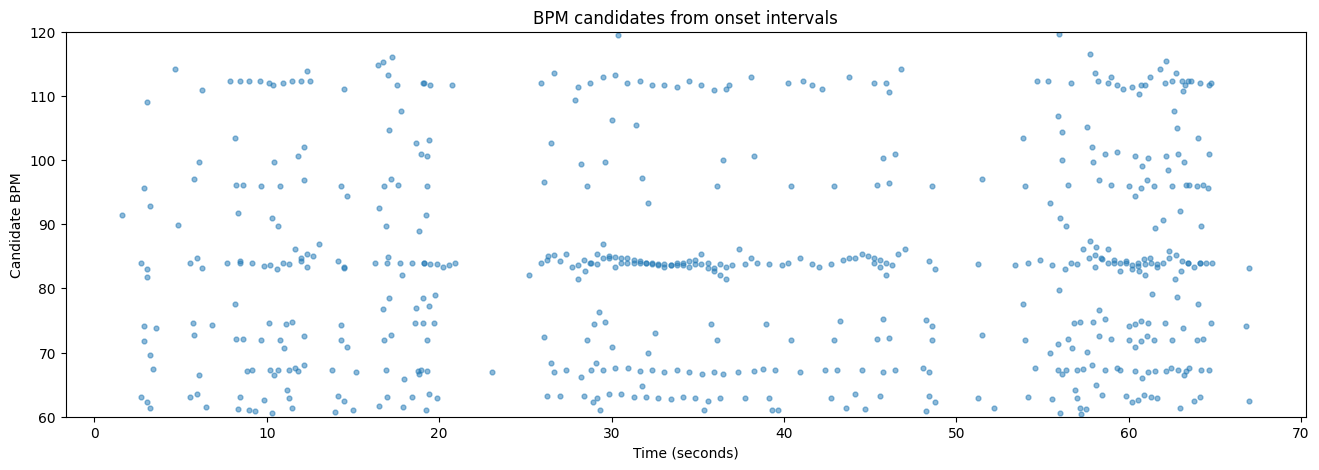

In [26]:
import matplotlib.pyplot as plt

candidate_times = np.asarray([
    (row["start_time"] + row["end_time"]) / 2
    for row in candidate_rows
])

candidate_bpms = np.asarray([
    row["bpm"]
    for row in candidate_rows
])

plt.figure(figsize=(16, 5))

plt.scatter(
    candidate_times,
    candidate_bpms,
    s=12,
    alpha=0.5,
)

plt.xlabel("Time (seconds)")
plt.ylabel("Candidate BPM")
plt.title("BPM candidates from onset intervals")
plt.ylim(60, 120)
plt.show()

In [33]:
REFERENCE_BPM = float(result["initial_bpm"])

for row in candidate_rows:
    row["reference_distance"] = abs(
        np.log2(row["bpm"] / REFERENCE_BPM)
    )

In [34]:
BPM_CHANGE_WEIGHT = 0.02
REFERENCE_WEIGHT = 0.03
STRENGTH_WEIGHT = 0.50
SKIP_WEIGHT = 0.20

In [35]:
peak_strengths = result["peak_strengths"]

candidate_rows = []

for i in range(len(peak_times)):
    for j in range(i + 1, min(i + 8, len(peak_times))):
        gap = peak_times[j] - peak_times[i]

        for beat_count in range(1, 5):
            bpm = 60 * beat_count / gap

            if 60 <= bpm <= 120:
                strength = (
                    peak_strengths[i]
                    + peak_strengths[j]
                ) / 2

                reference_distance = abs(
                    np.log2(
                        bpm / float(result["initial_bpm"])
                    )
                )

                candidate_rows.append({
                    "start_index": i,
                    "end_index": j,
                    "start_time": peak_times[i],
                    "end_time": peak_times[j],
                    "center_time": (
                        peak_times[i] + peak_times[j]
                    ) / 2,
                    "beat_count": beat_count,
                    "bpm": bpm,
                    "strength": strength,
                    "reference_distance": reference_distance,
                })

In [36]:
from collections import defaultdict

candidates_by_start = defaultdict(list)

for row in candidate_rows:
    candidates_by_start[row["start_index"]].append(row)

for start_index in candidates_by_start:
    candidates_by_start[start_index].sort(
        key=lambda row: (
            row["reference_distance"],
            -row["strength"],
        )
    )

    candidates_by_start[start_index] = (
        candidates_by_start[start_index][:6]
    )

In [37]:
def transition_cost(
    previous_row: dict,
    next_row: dict,
    bpm_change_weight: float = 0.03,
    reference_weight: float = 0.2,
    strength_weight: float = 0.5,
) -> float:
    bpm_change = abs(
        next_row["bpm"] - previous_row["bpm"]
    )

    return (
        bpm_change_weight * bpm_change
        + reference_weight
        * next_row["reference_distance"]
        - strength_weight
        * next_row["strength"]
    )

In [38]:
for start_index, rows in candidates_by_start.items():
    for row in rows:
        skipped_onsets = (
            row["end_index"]
            - row["start_index"]
            - 1
        )

        row["ranking_cost"] = (
            0.03 * row["reference_distance"]
            - 0.50 * row["strength"]
            + 0.20 * skipped_onsets
        )

    rows.sort(
        key=lambda row: row["ranking_cost"]
    )

    candidates_by_start[start_index] = rows[:8]

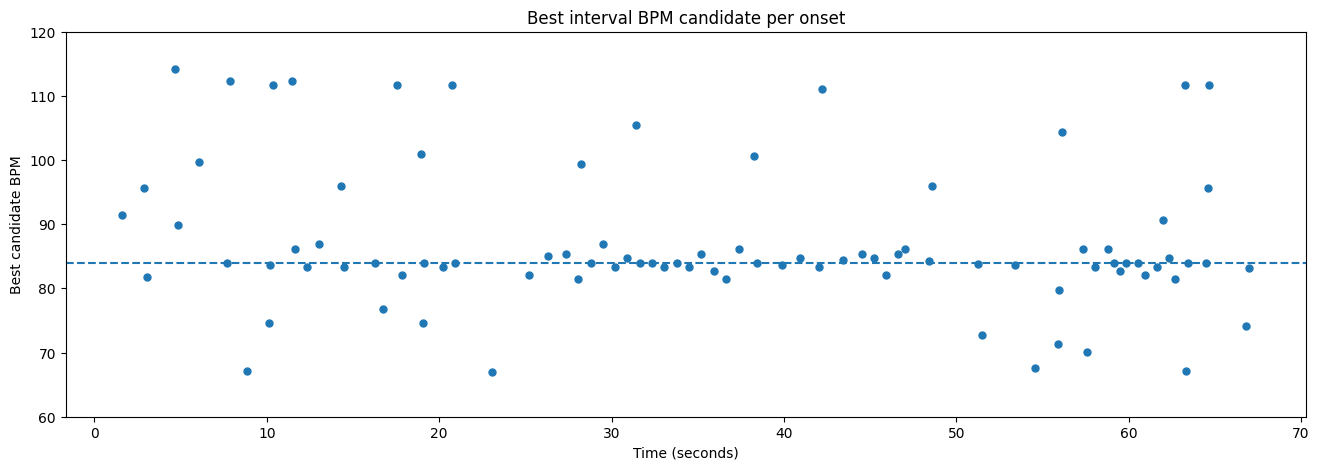

In [39]:
best_rows = [
    rows[0]
    for _, rows in sorted(candidates_by_start.items())
]

best_times = np.asarray([
    row["center_time"]
    for row in best_rows
])

best_bpms = np.asarray([
    row["bpm"]
    for row in best_rows
])

plt.figure(figsize=(16, 5))

plt.scatter(
    best_times,
    best_bpms,
    s=25,
)

plt.axhline(
    result["initial_bpm"],
    linestyle="--",
)

plt.xlabel("Time (seconds)")
plt.ylabel("Best candidate BPM")
plt.title("Best interval BPM candidate per onset")
plt.ylim(60, 120)
plt.show()

In [51]:
def find_best_bpm_path(
    candidate_rows: list[dict],
    *,
    bpm_change_weight: float = 0.03,
    redline_penalty: float = 0.15,
    reference_weight: float = 0.02,
    strength_weight: float = 0.50,
    skipped_onset_weight: float = 0.15,
) -> list[dict]:
    """
    Find a coherent path through onset-interval candidates.

    Consecutive edges must connect:

        previous end_index == next start_index

    A transition may either continue the current tempo or start
    a new timing section by paying a fixed redline penalty.
    """
    if not candidate_rows:
        return []

    rows_by_end: dict[int, list[int]] = {}

    for row_index, row in enumerate(candidate_rows):
        rows_by_end.setdefault(
            row["end_index"],
            [],
        ).append(row_index)

    n_rows = len(candidate_rows)

    best_cost = np.full(
        n_rows,
        np.inf,
        dtype=float,
    )

    previous_row = np.full(
        n_rows,
        -1,
        dtype=int,
    )

    used_redline_transition = np.zeros(
        n_rows,
        dtype=bool,
    )

    for row_index, row in enumerate(candidate_rows):
        skipped_onsets = (
            row["end_index"]
            - row["start_index"]
            - 1
        )

        edge_cost = (
            reference_weight
            * row["reference_distance"]
            - strength_weight
            * row["strength"]
            + skipped_onset_weight
            * skipped_onsets
            + alias_penalty(
                row["bpm"],
                float(result["initial_bpm"]),
            )
        )

        # Allow the path to begin at this candidate.
        best_cost[row_index] = edge_cost

        predecessors = rows_by_end.get(
            row["start_index"],
            [],
        )

        for predecessor_index in predecessors:
            predecessor = candidate_rows[
                predecessor_index
            ]

            if not np.isfinite(
                best_cost[predecessor_index]
            ):
                continue

            bpm_change = abs(
                row["bpm"]
                - predecessor["bpm"]
            )

            continuation_cost = (
                bpm_change_weight
                * bpm_change
            )

            used_redline = (
                redline_penalty
                < continuation_cost
            )

            change_cost = min(
                continuation_cost,
                redline_penalty,
            )

            transition_cost = (
                best_cost[predecessor_index]
                + edge_cost
                + change_cost
            )

            if transition_cost < best_cost[row_index]:
                best_cost[row_index] = transition_cost
                previous_row[row_index] = (
                    predecessor_index
                )
                used_redline_transition[row_index] = (
                    used_redline
                )

    latest_end = max(
        row["end_index"]
        for row in candidate_rows
    )

    ending_rows = [
        index
        for index, row in enumerate(candidate_rows)
        if row["end_index"] == latest_end
        and np.isfinite(best_cost[index])
    ]

    if not ending_rows:
        return []

    final_row = min(
        ending_rows,
        key=lambda index: best_cost[index],
    )

    path_indices = []

    while final_row != -1:
        path_indices.append(final_row)
        final_row = previous_row[final_row]

    path_indices.reverse()

    path = []

    for path_position, row_index in enumerate(path_indices):
        row = dict(candidate_rows[row_index])

        # The first path edge begins the first section but should not
        # be counted as a detected change from a previous section.
        row["starts_new_section"] = (
            path_position > 0
            and bool(
                used_redline_transition[row_index]
            )
        )

        row["path_cost"] = float(
            best_cost[row_index]
        )

        path.append(row)

    return path

In [47]:
def alias_penalty(
    bpm: float,
    reference_bpm: float,
) -> float:
    ratio = bpm / reference_bpm

    if ratio < 0.75 or ratio > 1.30:
        return 2.0

    return 0.0

In [54]:
best_path = find_best_bpm_path(
    candidate_rows,
    bpm_change_weight=0.03,
    redline_penalty=0.12,
    reference_weight=0.02,
    strength_weight=0.50,
    skipped_onset_weight=0.15,
)

print("Path edges:", len(best_path))

Path edges: 57


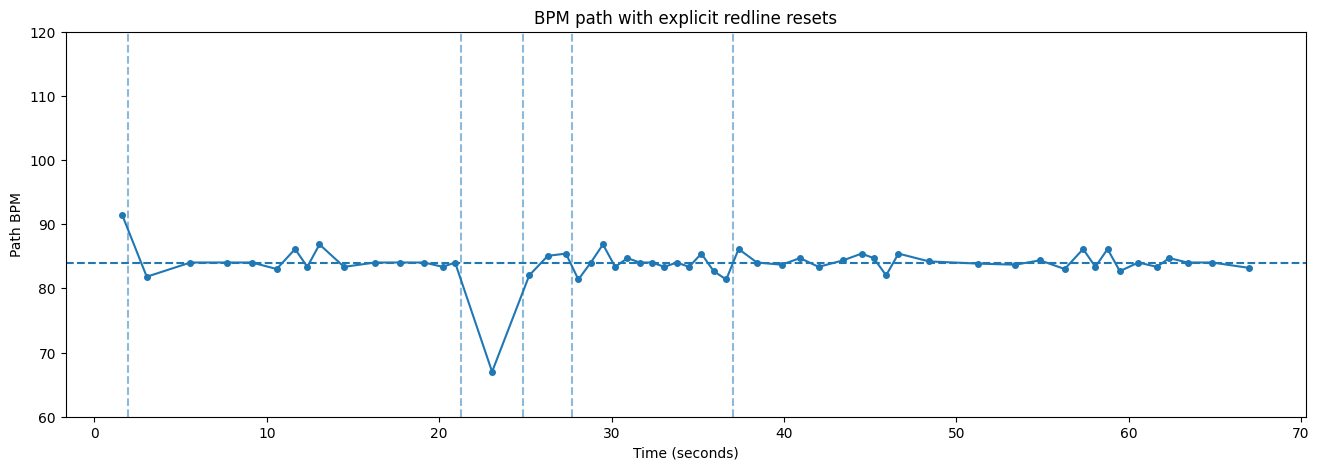

In [55]:
path_times = np.asarray([
    row["center_time"]
    for row in best_path
])

path_bpms = np.asarray([
    row["bpm"]
    for row in best_path
])

plt.figure(figsize=(16, 5))

plt.plot(
    path_times,
    path_bpms,
    marker="o",
    markersize=4,
)

for row in best_path:
    if row.get("starts_new_section", False):
        plt.axvline(
            row["start_time"],
            linestyle="--",
            alpha=0.5,
        )

plt.axhline(
    result["initial_bpm"],
    linestyle="--",
)

plt.xlabel("Time (seconds)")
plt.ylabel("Path BPM")
plt.title("BPM path with explicit redline resets")
plt.ylim(60, 120)
plt.show()

In [57]:
from pathlib import Path
import numpy as np


def parse_osu_file(osu_path: Path | str) -> dict:
    """
    Extract hit-object start times and uninherited timing points.

    Returned times are in seconds.
    """
    osu_path = Path(osu_path)

    if not osu_path.exists():
        raise FileNotFoundError(
            f".osu file not found: {osu_path.resolve()}"
        )

    sections: dict[str, list[str]] = {}
    current_section = None

    with osu_path.open(
        "r",
        encoding="utf-8-sig",
        errors="replace",
    ) as file:
        for raw_line in file:
            line = raw_line.strip()

            if not line or line.startswith("//"):
                continue

            if line.startswith("[") and line.endswith("]"):
                current_section = line[1:-1]
                sections.setdefault(current_section, [])
                continue

            if current_section is not None:
                sections[current_section].append(line)

    hit_objects = []

    for line in sections.get("HitObjects", []):
        parts = line.split(",")

        if len(parts) < 4:
            continue

        try:
            time_seconds = float(parts[2]) / 1000
            object_type = int(parts[3])
        except ValueError:
            continue

        hit_objects.append({
            "time": time_seconds,
            "type": object_type,
            "is_circle": bool(object_type & 1),
            "is_slider": bool(object_type & 2),
            "is_spinner": bool(object_type & 8),
            "is_hold": bool(object_type & 128),
        })

    redlines = []

    for line in sections.get("TimingPoints", []):
        parts = line.split(",")

        if len(parts) < 2:
            continue

        try:
            offset_seconds = float(parts[0]) / 1000
            beat_length_ms = float(parts[1])

            uninherited = (
                int(parts[6])
                if len(parts) > 6
                else 1
            )
        except ValueError:
            continue

        # Red timing point: uninherited and positive beat length.
        if uninherited == 1 and beat_length_ms > 0:
            redlines.append({
                "time": offset_seconds,
                "beat_length_ms": beat_length_ms,
                "bpm": 60000 / beat_length_ms,
            })

    hit_objects.sort(key=lambda item: item["time"])
    redlines.sort(key=lambda item: item["time"])

    return {
        "path": osu_path,
        "hit_objects": hit_objects,
        "object_times": np.asarray(
            [item["time"] for item in hit_objects],
            dtype=float,
        ),
        "redlines": redlines,
        "redline_times": np.asarray(
            [item["time"] for item in redlines],
            dtype=float,
        ),
        "redline_bpms": np.asarray(
            [item["bpm"] for item in redlines],
            dtype=float,
        ),
    }


osu_data = parse_osu_file(OSU_PATH)

print("Hit objects:", len(osu_data["hit_objects"]))
print("Red timing points:", len(osu_data["redlines"]))

for redline in osu_data["redlines"][:10]:
    print(
        f"{redline['time']:.3f}s, "
        f"{redline['bpm']:.3f} BPM"
    )

Hit objects: 132
Red timing points: 28
0.528s, 80.555 BPM
1.272s, 101.000 BPM
1.569s, 90.250 BPM
1.901s, 80.850 BPM
3.385s, 81.700 BPM
4.119s, 85.000 BPM
5.177s, 84.500 BPM
6.242s, 84.000 BPM
12.686s, 87.900 BPM
13.027s, 86.400 BPM


In [58]:
def score_objects_against_sections(
    object_times: np.ndarray,
    predicted_sections: list[dict],
    subdivisions: tuple[int, ...] = (1, 2, 3, 4),
) -> dict:
    """
    Calculate each object's distance from the nearest allowed
    subdivision of the predicted timing grid.
    """
    object_times = np.asarray(
        object_times,
        dtype=float,
    )

    object_errors = np.full(
        len(object_times),
        np.nan,
        dtype=float,
    )

    object_section_indices = np.full(
        len(object_times),
        -1,
        dtype=int,
    )

    object_subdivisions = np.full(
        len(object_times),
        -1,
        dtype=int,
    )

    for section_index, section in enumerate(predicted_sections):
        start_time = float(section["start_time"])
        end_time = float(section["end_time"])
        bpm = float(section["bpm"])

        # Local-tempo sections use phase; older sections may use offset.
        phase = float(
            section.get(
                "phase",
                section.get("offset", 0.0),
            )
        )

        period = 60.0 / bpm

        is_final_section = (
            section_index == len(predicted_sections) - 1
        )

        if is_final_section:
            mask = (
                (object_times >= start_time)
                & (object_times <= end_time)
            )
        else:
            mask = (
                (object_times >= start_time)
                & (object_times < end_time)
            )

        indices = np.flatnonzero(mask)

        for object_index in indices:
            object_time = object_times[object_index]

            best_error = np.inf
            best_subdivision = -1

            for subdivision in subdivisions:
                grid_step = period / subdivision

                nearest_grid_index = round(
                    (object_time - phase)
                    / grid_step
                )

                predicted_time = (
                    phase
                    + nearest_grid_index * grid_step
                )

                error = object_time - predicted_time

                if abs(error) < abs(best_error):
                    best_error = error
                    best_subdivision = subdivision

            object_errors[object_index] = best_error
            object_section_indices[object_index] = (
                section_index
            )
            object_subdivisions[object_index] = (
                best_subdivision
            )

    valid = np.isfinite(object_errors)
    absolute_errors_ms = (
        np.abs(object_errors[valid]) * 1000
    )

    return {
        "errors_seconds": object_errors,
        "errors_ms": object_errors * 1000,
        "absolute_errors_ms": absolute_errors_ms,
        "section_indices": object_section_indices,
        "subdivisions": object_subdivisions,
        "valid_mask": valid,
        "object_count": len(object_times),
        "scored_count": int(np.sum(valid)),
        "median_error_ms": (
            float(np.median(absolute_errors_ms))
            if len(absolute_errors_ms)
            else np.nan
        ),
        "percentile_95_ms": (
            float(np.percentile(absolute_errors_ms, 95))
            if len(absolute_errors_ms)
            else np.nan
        ),
        "maximum_error_ms": (
            float(np.max(absolute_errors_ms))
            if len(absolute_errors_ms)
            else np.nan
        ),
    }

In [59]:
object_score = score_objects_against_sections(
    object_times=osu_data["object_times"],
    predicted_sections=result["sections"],
    subdivisions=(1, 2, 3, 4),
)

print(
    "Objects scored:",
    object_score["scored_count"],
    "/",
    object_score["object_count"],
)

print(
    "Median absolute object error:",
    f"{object_score['median_error_ms']:.3f} ms",
)

print(
    "95th percentile object error:",
    f"{object_score['percentile_95_ms']:.3f} ms",
)

print(
    "Maximum object error:",
    f"{object_score['maximum_error_ms']:.3f} ms",
)

Objects scored: 128 / 132
Median absolute object error: 38.534 ms
95th percentile object error: 72.426 ms
Maximum object error: 105.828 ms


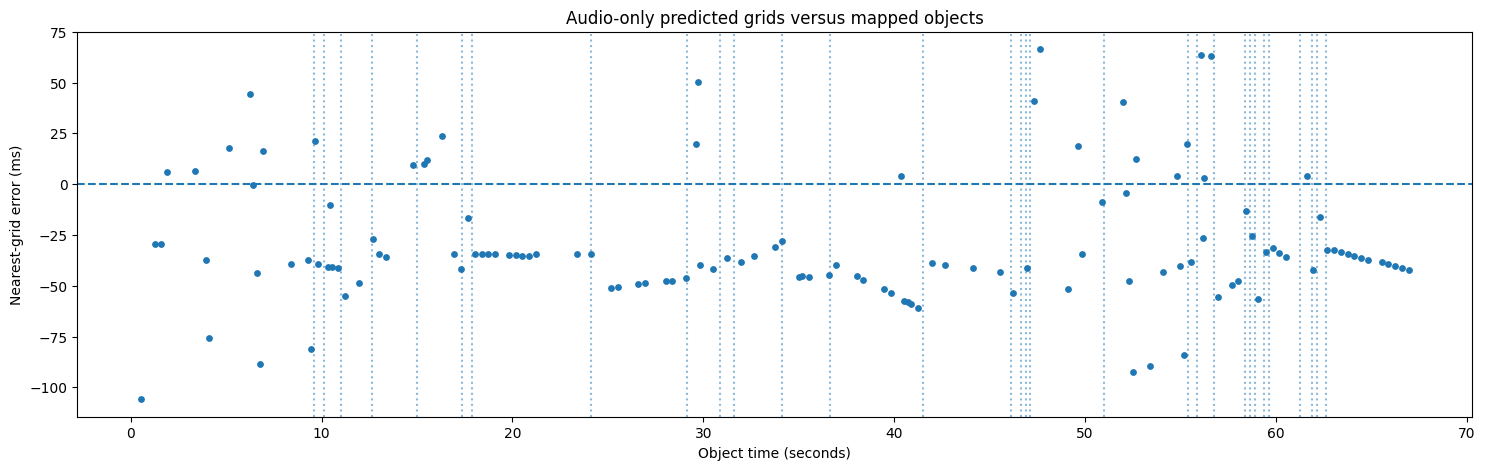

In [60]:
object_times = osu_data["object_times"]
valid = object_score["valid_mask"]
errors_ms = object_score["errors_ms"]

plt.figure(figsize=(18, 5))

plt.scatter(
    object_times[valid],
    errors_ms[valid],
    s=15,
)

plt.axhline(0, linestyle="--")

for section in result["sections"][1:]:
    plt.axvline(
        section["start_time"],
        linestyle=":",
        alpha=0.5,
    )

plt.xlabel("Object time (seconds)")
plt.ylabel("Nearest-grid error (ms)")
plt.title("Audio-only predicted grids versus mapped objects")
plt.show()

In [61]:
comparison = compare_redlines(
    ground_truth_times=osu_data["redline_times"],
    ground_truth_bpms=osu_data["redline_bpms"],
    detected_times=np.asarray([
        section["start_time"]
        for section in result["sections"][1:]
    ]),
    detected_bpms=np.asarray([
        float(section["bpm"])
        for section in result["sections"][1:]
    ]),
    time_tolerance=0.300,
)

print("Redline precision:", comparison["precision"])
print("Redline recall:", comparison["recall"])
print("Redline F1:", comparison["f1"])

Redline precision: 0.25806451612903225
Redline recall: 0.2857142857142857
Redline F1: 0.2711864406779661


In [62]:
from copy import deepcopy


def shift_predicted_sections(
    sections: list[dict],
    shift_seconds: float,
) -> list[dict]:
    shifted = deepcopy(sections)

    for section in shifted:
        if "phase" in section:
            section["phase"] = (
                float(section["phase"])
                + shift_seconds
            )

        if "offset" in section:
            section["offset"] = (
                float(section["offset"])
                + shift_seconds
            )

    return shifted

In [63]:
shift_candidates_ms = np.linspace(
    -100,
    100,
    401,
)

shift_scores = []

for shift_ms in shift_candidates_ms:
    shifted_sections = shift_predicted_sections(
        result["sections"],
        shift_seconds=shift_ms / 1000,
    )

    score = score_objects_against_sections(
        object_times=osu_data["object_times"],
        predicted_sections=shifted_sections,
        subdivisions=(1, 2, 3, 4),
    )

    shift_scores.append({
        "shift_ms": float(shift_ms),
        "median_ms": score["median_error_ms"],
        "p95_ms": score["percentile_95_ms"],
    })

best_shift_result = min(
    shift_scores,
    key=lambda row: row["median_ms"],
)

best_shift_result

{'shift_ms': -40.5, 'median_ms': 7.13002910702798, 'p95_ms': 63.92073838264553}

In [64]:
print(
    "Raw median error:",
    f"{object_score['median_error_ms']:.3f} ms",
)

print(
    "Best diagnostic shift:",
    f"{best_shift_result['shift_ms']:.3f} ms",
)

print(
    "Shift-corrected median:",
    f"{best_shift_result['median_ms']:.3f} ms",
)

print(
    "Shift-corrected 95th percentile:",
    f"{best_shift_result['p95_ms']:.3f} ms",
)

Raw median error: 38.534 ms
Best diagnostic shift: -40.500 ms
Shift-corrected median: 7.130 ms
Shift-corrected 95th percentile: 63.921 ms


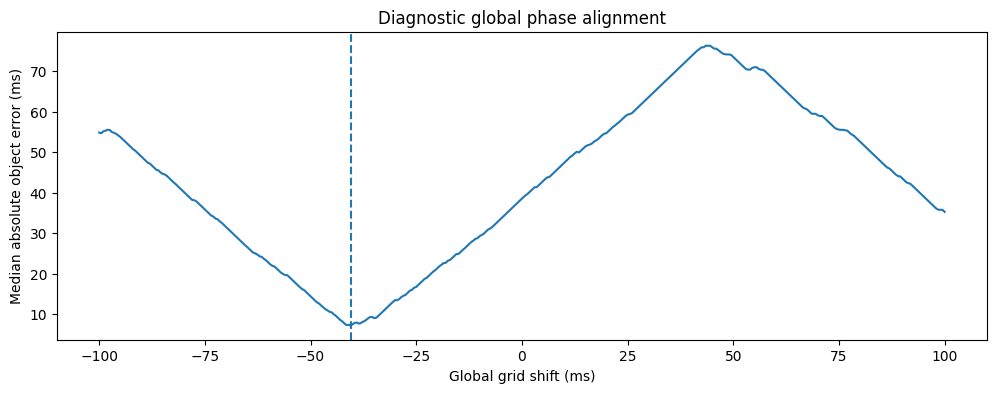

In [65]:
plt.figure(figsize=(12, 4))

plt.plot(
    [row["shift_ms"] for row in shift_scores],
    [row["median_ms"] for row in shift_scores],
)

plt.axvline(
    best_shift_result["shift_ms"],
    linestyle="--",
)

plt.xlabel("Global grid shift (ms)")
plt.ylabel("Median absolute object error (ms)")
plt.title("Diagnostic global phase alignment")
plt.show()

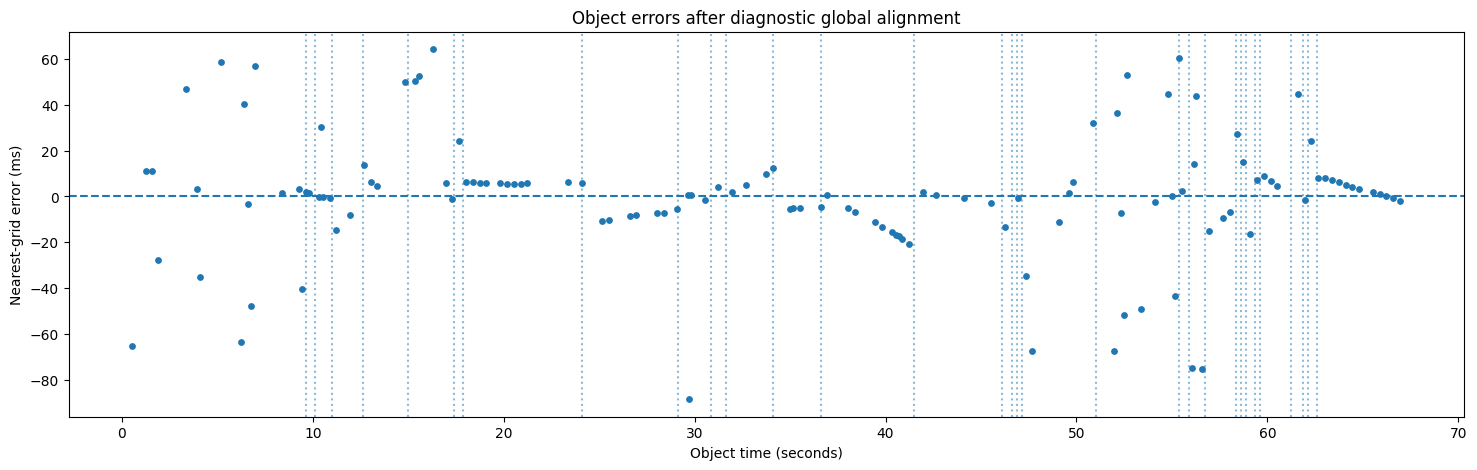

In [66]:
diagnostic_sections = shift_predicted_sections(
    result["sections"],
    best_shift_result["shift_ms"] / 1000,
)

shifted_object_score = score_objects_against_sections(
    object_times=osu_data["object_times"],
    predicted_sections=diagnostic_sections,
    subdivisions=(1, 2, 3, 4),
)

valid = shifted_object_score["valid_mask"]

plt.figure(figsize=(18, 5))

plt.scatter(
    osu_data["object_times"][valid],
    shifted_object_score["errors_ms"][valid],
    s=15,
)

plt.axhline(0, linestyle="--")

for section in diagnostic_sections[1:]:
    plt.axvline(
        section["start_time"],
        linestyle=":",
        alpha=0.5,
    )

plt.xlabel("Object time (seconds)")
plt.ylabel("Nearest-grid error (ms)")
plt.title(
    "Object errors after diagnostic global alignment"
)
plt.show()

In [67]:
def summarize_object_errors(
    object_score: dict,
) -> dict:
    absolute_errors_ms = np.asarray(
        object_score["absolute_errors_ms"],
        dtype=float,
    )

    thresholds_ms = [2, 5, 10, 20, 40]

    summary = {
        "count": len(absolute_errors_ms),
        "mean_ms": float(
            np.mean(absolute_errors_ms)
        ),
        "median_ms": float(
            np.median(absolute_errors_ms)
        ),
        "p90_ms": float(
            np.percentile(
                absolute_errors_ms,
                90,
            )
        ),
        "p95_ms": float(
            np.percentile(
                absolute_errors_ms,
                95,
            )
        ),
        "maximum_ms": float(
            np.max(absolute_errors_ms)
        ),
    }

    for threshold_ms in thresholds_ms:
        summary[
            f"within_{threshold_ms}ms"
        ] = float(
            np.mean(
                absolute_errors_ms
                <= threshold_ms
            )
        )

    return summary

In [68]:
summary = summarize_object_errors(
    shifted_object_score
)

for key, value in summary.items():
    if key.startswith("within_"):
        print(
            f"{key}: {100 * value:.1f}%"
        )
    elif key != "count":
        print(
            f"{key}: {value:.3f}"
        )
    else:
        print(
            f"{key}: {value}"
        )

count: 128
mean_ms: 17.740
median_ms: 7.130
p90_ms: 51.906
p95_ms: 63.921
maximum_ms: 88.364
within_2ms: 16.4%
within_5ms: 30.5%
within_10ms: 57.8%
within_20ms: 72.7%
within_40ms: 80.5%


In [69]:
def summarize_errors_by_section(
    object_times: np.ndarray,
    object_score: dict,
    predicted_sections: list[dict],
) -> list[dict]:
    errors_ms = np.asarray(
        object_score["errors_ms"],
        dtype=float,
    )

    section_indices = np.asarray(
        object_score["section_indices"],
        dtype=int,
    )

    summaries = []

    for section_index, section in enumerate(
        predicted_sections
    ):
        mask = (
            (section_indices == section_index)
            & np.isfinite(errors_ms)
        )

        times = object_times[mask]
        errors = errors_ms[mask]

        if len(errors) == 0:
            continue

        absolute_errors = np.abs(errors)

        # Residual slope in ms of error per second.
        if len(errors) >= 2:
            slope, intercept = np.polyfit(
                times,
                errors,
                deg=1,
            )
        else:
            slope = np.nan
            intercept = np.nan

        summaries.append({
            "section_index": section_index,
            "start_time": float(
                section["start_time"]
            ),
            "end_time": float(
                section["end_time"]
            ),
            "bpm": float(section["bpm"]),
            "object_count": len(errors),
            "median_signed_ms": float(
                np.median(errors)
            ),
            "median_absolute_ms": float(
                np.median(absolute_errors)
            ),
            "p95_absolute_ms": float(
                np.percentile(
                    absolute_errors,
                    95,
                )
            ),
            "residual_slope_ms_per_second": (
                float(slope)
            ),
        })

    return summaries

In [70]:
section_error_summary = (
    summarize_errors_by_section(
        object_times=osu_data["object_times"],
        object_score=shifted_object_score,
        predicted_sections=diagnostic_sections,
    )
)

for row in section_error_summary:
    print(
        f"Section {row['section_index']:2d} | "
        f"{row['start_time']:6.2f}"
        f"–{row['end_time']:6.2f}s | "
        f"{row['bpm']:7.3f} BPM | "
        f"n={row['object_count']:3d} | "
        f"median={row['median_absolute_ms']:6.2f} ms | "
        f"p95={row['p95_absolute_ms']:6.2f} ms | "
        f"slope={row['residual_slope_ms_per_second']:+7.2f} ms/s"
    )

Section  0 |   0.00–  9.62s |  67.400 BPM | n= 16 | median= 37.74 ms | p95= 63.95 ms | slope=  +0.85 ms/s
Section  1 |   9.62– 10.12s |  83.500 BPM | n=  2 | median=  1.68 ms | p95=  1.97 ms | slope=  -3.58 ms/s
Section  2 |  10.12– 11.00s |  83.900 BPM | n=  4 | median=  0.47 ms | p95= 25.69 ms | slope= -21.19 ms/s
Section  3 |  11.00– 12.00s |  84.700 BPM | n=  2 | median= 11.41 ms | p95= 14.39 ms | slope=  +9.26 ms/s
Section  4 |  12.62– 15.00s |  86.100 BPM | n=  4 | median=  9.89 ms | p95= 44.55 ms | slope= +20.18 ms/s
Section  5 |  15.00– 17.38s |  82.400 BPM | n=  5 | median= 50.34 ms | p95= 61.78 ms | slope= -28.73 ms/s
Section  6 |  17.38– 17.88s |  83.600 BPM | n=  1 | median= 24.06 ms | p95= 24.06 ms | slope=   +nan ms/s
Section  7 |  17.88– 24.12s |  84.000 BPM | n= 11 | median=  5.93 ms | p95=  6.29 ms | slope=  -0.03 ms/s
Section  8 |  24.12– 29.12s |  84.100 BPM | n=  7 | median=  8.14 ms | p95= 10.46 ms | slope=  +1.21 ms/s
Section  9 |  29.12– 30.88s |  83.800 BPM | n=

In [71]:
def classify_section_quality(
    section_summary: dict,
    *,
    min_objects: int = 3,
    good_median_ms: float = 10.0,
    acceptable_median_ms: float = 20.0,
    good_slope_ms_per_second: float = 3.0,
    acceptable_slope_ms_per_second: float = 8.0,
) -> str:
    object_count = section_summary["object_count"]
    median_error = section_summary["median_absolute_ms"]
    slope = section_summary[
        "residual_slope_ms_per_second"
    ]

    if object_count < min_objects:
        return "insufficient evidence"

    absolute_slope = (
        abs(slope)
        if np.isfinite(slope)
        else np.inf
    )

    if (
        median_error <= good_median_ms
        and absolute_slope
        <= good_slope_ms_per_second
    ):
        return "good"

    if (
        median_error <= acceptable_median_ms
        and absolute_slope
        <= acceptable_slope_ms_per_second
    ):
        return "acceptable"

    return "bad"

In [72]:
def classify_section_quality(
    section_summary: dict,
    *,
    min_objects: int = 3,
    good_median_ms: float = 10.0,
    acceptable_median_ms: float = 20.0,
    good_slope_ms_per_second: float = 3.0,
    acceptable_slope_ms_per_second: float = 8.0,
) -> str:
    object_count = section_summary["object_count"]
    median_error = section_summary["median_absolute_ms"]
    slope = section_summary[
        "residual_slope_ms_per_second"
    ]

    if object_count < min_objects:
        return "insufficient evidence"

    absolute_slope = (
        abs(slope)
        if np.isfinite(slope)
        else np.inf
    )

    if (
        median_error <= good_median_ms
        and absolute_slope
        <= good_slope_ms_per_second
    ):
        return "good"

    if (
        median_error <= acceptable_median_ms
        and absolute_slope
        <= acceptable_slope_ms_per_second
    ):
        return "acceptable"

    return "bad"

In [73]:
def bpm_plausibility_penalty(
    bpm: float,
    reference_bpm: float,
    *,
    soft_fraction: float = 0.15,
    hard_fraction: float = 0.22,
    hard_penalty: float = 5.0,
) -> float:
    relative_difference = abs(
        bpm - reference_bpm
    ) / reference_bpm

    if relative_difference >= hard_fraction:
        return hard_penalty

    if relative_difference <= soft_fraction:
        return 0.0

    position = (
        relative_difference - soft_fraction
    ) / (
        hard_fraction - soft_fraction
    )

    return hard_penalty * position**2